📁 Please upload your UCI_Credit_Card.csv file:


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv

Class distribution before cleaning:
 default
0    23364
1     6636
Name: count, dtype: int64

⚠️ Outlier removal dropped minority class — reverting to unfiltered dataset.

✅ Cleaning complete. Shape: (29965, 24)
Class balance after cleaning:
 default
0    23335
1     6630
Name: count, dtype: int64

Before Resampling:
 default
0    16334
1     4641
Name: count, dtype: int64

After SMOTE:
 default
1    16334
0    16334
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


✅ Selected Features (RFE): ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1']

✅ Final Preprocessed Data Shapes: 
X_train: (32668, 10) 
X_test: (8990, 10)


/tmp/ipython-input-2292213356.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette="coolwarm")


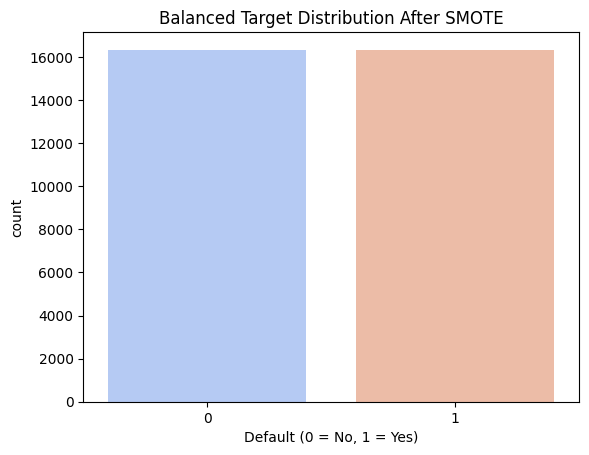

In [1]:
# ==========================================
# 📦 INSTALL REQUIRED LIBRARIES
# ==========================================
!pip install imbalanced-learn --quiet
!pip install seaborn --quiet
!pip install matplotlib --quiet
!pip install scikit-learn --quiet

# ==========================================
# 📚 IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# ==========================================
# 📂 UPLOAD DATA FILE MANUALLY
# ==========================================
from google.colab import files
print("📁 Please upload your UCI_Credit_Card.csv file:")
uploaded = files.upload()

# ==========================================
# 🧹 LOAD AND CLEAN DATA
# ==========================================
df = pd.read_csv("UCI_Credit_Card.csv")

if "default.payment.next.month" in df.columns:
    df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
if "ID" in df.columns:
    df.drop(columns="ID", inplace=True)

# Show class distribution before cleaning
print("\nClass distribution before cleaning:\n", df["default"].value_counts())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Remove outliers — careful to retain class balance
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# If cleaning removes all defaults, revert to original data
if df_cleaned["default"].nunique() < 2:
    print("\n⚠️ Outlier removal dropped minority class — reverting to unfiltered dataset.")
    df = df.copy()
else:
    df = df_cleaned

print(f"\n✅ Cleaning complete. Shape: {df.shape}")
print("Class balance after cleaning:\n", df["default"].value_counts())

# ==========================================
# ✂️ TRAIN-TEST SPLIT (Stratified)
# ==========================================
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nBefore Resampling:\n", y_train.value_counts())

# ==========================================
# ⚖️ BALANCE DATA USING SMOTE
# ==========================================
if len(y_train.unique()) == 2:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("\nAfter SMOTE:\n", y_train_res.value_counts())
else:
    print("\n⚠️ Only one class in training data — cannot apply SMOTE.")
    X_train_res, y_train_res = X_train, y_train


# ==========================================
# 🧠 FEATURE SELECTION (Filter + Wrapper)
# ==========================================
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression

# Filter Method (ANOVA F-test)
filter_sel = SelectKBest(score_func=f_classif, k=min(15, X_train_res.shape[1]-1))
X_train_filter = filter_sel.fit_transform(X_train_res, y_train_res)
X_test_filter = filter_sel.transform(X_test)
selected_filter = X_train.columns[filter_sel.get_support()]

# Wrapper (RFE) with more iterations for convergence
estimator = LogisticRegression(max_iter=2000)  # ✅ increased from 1000 to 2000
rfe = RFE(estimator, n_features_to_select=min(10, X_train_filter.shape[1]))
rfe.fit(X_train_filter, y_train_res)
selected_wrapper = selected_filter[rfe.support_]

print("\n✅ Selected Features (RFE):", list(selected_wrapper))


# ==========================================
# 🔄 NORMALIZE NUMERICAL FEATURES
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res[selected_wrapper])
X_test_scaled = scaler.transform(X_test[selected_wrapper])

print("\n✅ Final Preprocessed Data Shapes:",
      "\nX_train:", X_train_scaled.shape,
      "\nX_test:", X_test_scaled.shape)

# ==========================================
# 📊 VISUALIZE CLASS BALANCE
# ==========================================
sns.countplot(x=y_train_res, palette="coolwarm")
plt.title("Balanced Target Distribution After SMOTE")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.show()

In [3]:
# ====== 3) LightGBM + GridSearchCV ======
# install lightgbm if required: !pip install lightgbm
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_clf = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "num_leaves": [31, 50, 80],
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_samples": [20, 40, 60]
}

grid_lgb = GridSearchCV(
    lgb_clf,
    param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train_scaled, y_train_res)

print("LightGBM - Best params:", grid_lgb.best_params_)
print("LightGBM - Best CV accuracy: {:.4f}".format(grid_lgb.best_score_))

best_lgb = grid_lgb.best_estimator_
y_pred = best_lgb.predict(X_test_scaled)
print("\nLightGBM - Test accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nLightGBM - Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 16334, number of negative: 16334
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 342
[LightGBM] [Info] Number of data points in the train set: 32668, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM - Best params: {'learning_rate': 0.1, 'min_child_samples': 60, 'n_estimators': 300, 'num_leaves': 31}
LightGBM - Best CV accuracy: 0.7808

LightGBM - Test accuracy: 0.7575

LightGBM - Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      7001
           1       0.45      0.47      0.46      1989

    accuracy                           0.76      8990
 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [4]:
# ====== 4) XGBoost + GridSearchCV ======
# install xgboost if required: !pip install xgboost
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_scaled, y_train_res)

print("XGBoost - Best params:", grid_xgb.best_params_)
print("XGBoost - Best CV accuracy: {:.4f}".format(grid_xgb.best_score_))

best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)
print("\nXGBoost - Test accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nXGBoost - Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:27:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.6}
XGBoost - Best CV accuracy: 0.7813

XGBoost - Test accuracy: 0.7534

XGBoost - Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      7001
           1       0.45      0.48      0.46      1989

    accuracy                           0.75      8990
   macro avg       0.65      0.65      0.65      8990
weighted avg       0.76      0.75      0.76      8990



In [ ]:
# ====== 2) SVM (SVC) + GridSearchCV ======
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svc = SVC(probability=True, random_state=42)

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "poly", "linear"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3]  # used only for poly
}

grid_svc = GridSearchCV(
    svc,
    param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train_scaled, y_train_res)

print("SVM - Best params:", grid_svc.best_params_)
print("SVM - Best CV accuracy: {:.4f}".format(grid_svc.best_score_))

best_svc = grid_svc.best_estimator_
y_pred = best_svc.predict(X_test_scaled)
print("\nSVM - Test accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nSVM - Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
